# Landscape connectivity indicators for Tasmania

This notebook walks through the four indicators provided by `connectivity`, using the
example rasters bundled with the package:

| Indicator | Function | Notes |
| --- | --- | --- |
| Connectedness | `connectedness(..., option=1)` | condition-weighted connectivity of the surrounding landscape |
| Connected habitat | `connectedness(..., option=3)` | connectedness multiplied by local condition |
| PARC-connectedness | `connectedness(..., pa_file=...)` | weighted by the proportion of each cell under protection |
| BERI | `beri(...)` | Bioclimatic Ecosystem Resilience Index under climate scenarios |

Everything runs on data shipped with the library, so no downloads or local paths
are needed. The whole notebook takes well under a minute on a modern laptop.

**Bundled data.** Tasmania, Australia at 30 arc-second resolution (588 x 516 cells,
EPSG:4326, roughly 1 km). See `connectivity/data/README.md` for sources and licensing.

**Extra requirement.** Plotting uses `matplotlib`, which is not a dependency of
`connectivity` itself:

```
pip install matplotlib
```

In [1]:
import os

import numpy as np
import rasterio

from connectivity import beri, connectedness, resolution_info, example_data_path

In [2]:
import matplotlib.pyplot as plt

## 1. The bundled data

`example_data_path()` resolves a dataset name to a file path inside the installed package,
so these calls work from any working directory.

In [3]:
condition_file = example_data_path("site_condition")
condition_file

'/opt/miniconda3/envs/spatial/lib/python3.13/site-packages/connectivity/data/site_condition.tif'

In [4]:
with rasterio.open(condition_file) as ds:
    cond = ds.read(1, masked=True)
    meta = ds.meta
    print(f"{ds.width} x {ds.height} cells, {ds.crs}, {ds.res[0]:.6f} degrees")

print(f"condition range: {cond.min():.3f} - {cond.max():.3f}")

588 x 516 cells, EPSG:4326, 0.008333 degrees
condition range: 0.000 - 0.969


## 2. Choosing resolution levels

The algorithm builds its own overview pyramid on the fly, so the input raster does
not need pre-computed GeoTIFF overviews. `resolution_info()` shows what each level
costs and how far the search reaches:

```
max-reach = outer_window * max(levels) * resolution
```

Levels that shrink the grid below ~16 cells get flagged — for this raster anything
past 32 is too coarse to be useful.

In [5]:
resolution_info(condition_file, outer_window=7)


File: /opt/miniconda3/envs/spatial/lib/python3.13/site-packages/connectivity/data/site_condition.tif
Base raster: 588 x 516 cells (303.41K total)
Base resolution: 0.008333 degrees
CRS: EPSG:4326
Bands: 1
Data type(s): float32
Nodata: -9999.0
Outer window: 7
Small-dimension warning threshold: < 16 cells
Distance note: approximate km values use centre latitude -41.550

Candidate internally generated levels:
  Level    Width   Height      Cells   % base           Resolution            Reach     Reach km  Note
      1      588      516    303.41K 100.000%     0.008333 degrees  0.05833 degrees     6.494 km  
      2      294      258     75.85K  25.000%      0.01667 degrees   0.1167 degrees     12.99 km  
      4      147      129     18.96K   6.250%      0.03333 degrees   0.2333 degrees     25.97 km  
      8       74       65      4.81K   1.585%      0.06667 degrees   0.4667 degrees     51.95 km  
     16       37       33      1.22K   0.402%       0.1333 degrees   0.9333 degrees     103

## 3. Connectedness

`option=1` returns connectedness itself: how well each cell is linked to
condition-weighted habitat in the surrounding landscape.

`lambdas` are dispersal-scale parameters in km, and `n_threads=None` uses all
available cores. The same settings are repeated in each call below so every cell
stands on its own.

In [6]:
%%time
conns = connectedness(
    condition_file = condition_file,
    lambdas = [2, 20, 50],
    max_cost = 2.0,
    window_size = 5,
    outer_window = 7,
    levels = [2, 4, 8, 16, 32],
    option = 1,
    window_mode = "circular",
    n_threads = None
)

CPU times: user 1min 9s, sys: 955 ms, total: 1min 10s
Wall time: 6.39 s


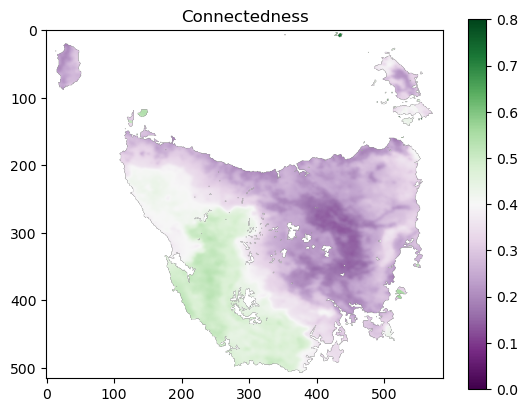

In [7]:
plt.imshow(conns, cmap="PRGn", vmin=0, vmax=0.8)
plt.colorbar()
plt.title("Connectedness")
plt.show()

## 4. Connected habitat

`option=3` multiplies connectedness by the cell's own condition, so a well-connected
but degraded cell scores low.

In [8]:
%%time
conns2 = connectedness(
    condition_file = condition_file,
    lambdas = [2, 20, 50],
    max_cost = 2.0,
    window_size = 5,
    outer_window = 7,
    levels = [2, 4, 8, 16, 32],
    option = 3,
    window_mode = "circular",
    n_threads = None
)

CPU times: user 1min 9s, sys: 1.36 s, total: 1min 10s
Wall time: 6.43 s


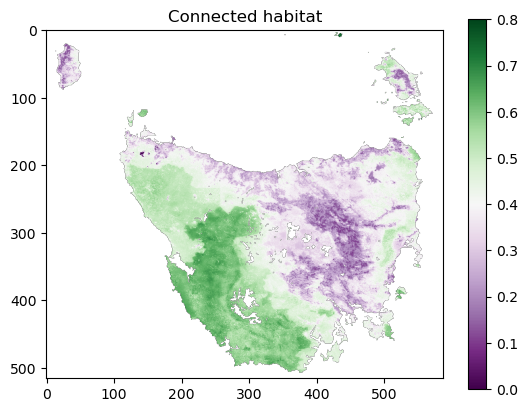

In [9]:
plt.imshow(conns2, cmap="PRGn", vmin=0, vmax=0.8)
plt.colorbar()
plt.title("Connected habitat")
plt.show()

## 5. PARC-connectedness

Passing `pa_file` weights connectedness by the proportion of each cell under
protection, giving PARC-connectedness (Protected Area Connectedness Index). The bundled `pa_proportion` layer holds those proportions as
values in 0-1 on the same grid as the condition raster.

To use your own protected-area layer, point `pa_file` at it — it must match the
condition raster's shape, extent and resolution exactly (588 x 516 here).

In [10]:
pa_file = example_data_path("pa_proportion")

with rasterio.open(pa_file) as ds:
    pa = ds.read(1, masked=True)

print(f"proportion protected: {pa.min():.3f} - {pa.max():.3f}, mean {pa.mean():.3f}")

proportion protected: 0.000 - 1.000, mean 0.423


In [11]:
%%time
parc = connectedness(
    condition_file = condition_file,
    pa_file = pa_file,
    pa_to_pa = False,
    lambdas = [2, 20, 50],
    max_cost = 2,
    window_size = 5,
    outer_window = 7,
    levels = [2, 4, 8, 16, 32],
    window_mode = "circular",
    n_threads = None
)

CPU times: user 33.4 s, sys: 940 ms, total: 34.4 s
Wall time: 3.13 s


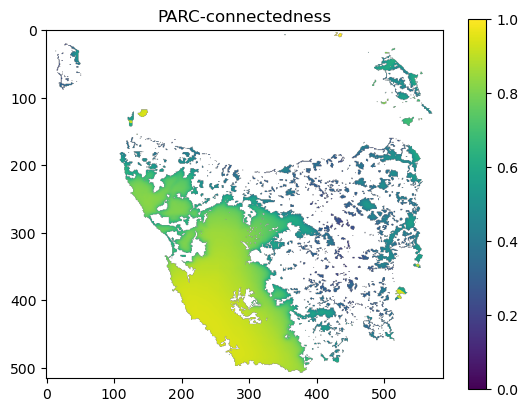

In [12]:
plt.imshow(parc, cmap="viridis", vmin=0, vmax=1)
plt.colorbar()
plt.title("PARC-connectedness")
plt.show()

## 6. BERI

BERI combines habitat connectedness with projected compositional turnover to
estimate how much biodiversity a landscape can retain under future climates.

The bundled `transgrids` are 19-band compositional turnover layers: `1990` is the
current baseline, the rest are future scenarios.

In [13]:
scenario_names = [
    "ACC50_85", "GFD50_85", "IPS50_26",
    "IPS50_45", "IPS50_60", "IPS50_85",
]
current_file = example_data_path("transgrids/1990")
scenarios = [example_data_path(f"transgrids/{name}") for name in scenario_names]

for path in scenarios:
    print(os.path.basename(path))

ACC50_85.tif
GFD50_85.tif
IPS50_26.tif
IPS50_45.tif
IPS50_60.tif
IPS50_85.tif


In [14]:
resolution_info(current_file, outer_window=7)


File: /opt/miniconda3/envs/spatial/lib/python3.13/site-packages/connectivity/data/transgrids/1990.tif
Base raster: 588 x 516 cells (303.41K total)
Base resolution: 0.008333 degrees
CRS: EPSG:4326
Bands: 19
Data type(s): float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32
Nodata: nan
Outer window: 7
Small-dimension warning threshold: < 16 cells
Distance note: approximate km values use centre latitude -41.550

Candidate internally generated levels:
  Level    Width   Height      Cells   % base           Resolution            Reach     Reach km  Note
      1      588      516    303.41K 100.000%     0.008333 degrees  0.05833 degrees     6.494 km  
      2      294      258     75.85K  25.000%      0.01667 degrees   0.1167 degrees     12.99 km  
      4      147      129     18.96K   6.250%      0.03333 degrees   0.2333 degrees     25.97 km  
      8       74       65     

In [15]:
%%time
beri_map = beri(
    condition_file = condition_file,
    current_file = current_file,
    future_files = scenarios,
    lambdas = [2, 20, 50],
    max_cost = 2.0,
    window_size = 5,
    outer_window = 7,
    levels = [2, 4, 8, 16, 32],
    window_mode = "circular",
    n_threads = None,
)

CPU times: user 1min 30s, sys: 5.37 s, total: 1min 36s
Wall time: 8.95 s


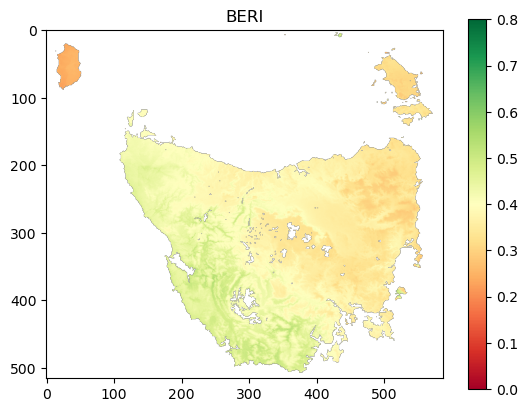

In [16]:
plt.imshow(beri_map, cmap="RdYlGn", vmin=0, vmax=0.8)
plt.colorbar()
plt.title("BERI")
plt.show()

## 7. All indicators side by side

The five panels together: input condition, the two connectedness variants,
PARC-connectedness and BERI, cropped to the Tasmanian mainland.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

def plot_four_indicators(condition, connectedness, connhabitat, parc_con, beri, meta):
    arrays = [condition, connectedness, connhabitat, parc_con, beri]
    titles = ["(a) Habitat condition", "(b) Connectedness", "(c) Connected Habitat", "(d) PARC-connectedness", "(e) BERI"]
    cmaps = ["PRGn", "PRGn", "PRGn", "viridis", "RdYlGn"]

    height, width = condition.shape

    # rasterio returns: west, south, east, north
    left, bottom, right, top = array_bounds(height, width, meta["transform"])
    extent = [left, right, bottom, top]

    fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
    axes = axes.ravel()

    fig.delaxes(axes[5])   # remove unused sixth panel
    axes = axes[:5]        # keep only the five real map axes

    for idx, (ax, arr, title, cmap) in enumerate(zip(axes, arrays, titles, cmaps)):
        img = ax.imshow(
            arr,
            extent=extent,
            origin="upper",
            cmap=cmap,
            vmin=0,
            vmax= 0.8 if idx == 4 else 1,
        )

        ax.set_title(title, fontsize=12)
        ax.set_facecolor("white")

        mean_lat = (bottom + top) / 2
        aspect = 1 / np.cos(np.deg2rad(mean_lat))
        ax.set_aspect(aspect)

        ax.tick_params(
            bottom=False, labelbottom=False,
            left=False, labelleft=False,
            right=False, labelright=False,
            top=False, labeltop=False
        )

        if idx in [3, 4]:
            ax.tick_params(bottom=True, labelbottom=True)
            ax.set_xlabel("Longitude")

        if idx in [0, 3]:
            ax.tick_params(left=True, labelleft=True)
            ax.set_ylabel("Latitude")

        cbar = fig.colorbar(img, ax=ax, fraction=0.035, pad=0.02)
        cbar.ax.tick_params(labelsize=8)

    # Crop to Tasmania-ish extent
    for ax in axes:
        ax.set_xlim(144.4, 148.6)
        ax.set_ylim(-43.7, -40.6)

    return fig, axes

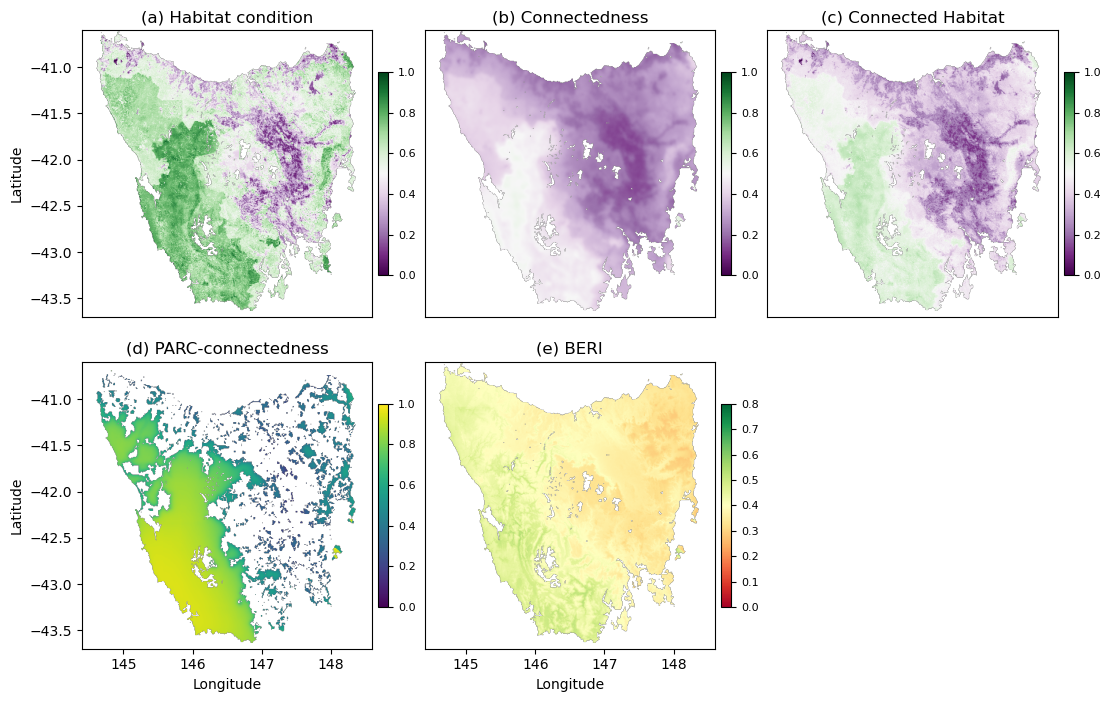

In [18]:
plot_four_indicators(cond, conns, conns2, parc, beri_map, meta)
plt.show()